In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import torch
import pytorch_lightning as pl
from sklearn.model_selection import train_test_split
import pretty_midi
import IPython.display
from tqdm import tqdm


REPO_ROOT = Path('.').resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


from src.data.dataset import (
    PianoMmapDataset, 
    identify_chord, 
    process_to_monophonic_continuous, 
    SAMPLES_PER_BAR
)

# Modelli e Training
from src.models.base_model import PianoGAN
from src.training.trainer import LightningTrainer

# Utility e Visualizzazione
from src.utils.tools import piano_roll_to_pretty_midi
from src.utils.visualization import display_prettymidi

/Users/Edoardo/NNDL-project/venv_deep/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Istanza del modello
NOISE_DIM = 100
model = PianoGAN(noise_dim=NOISE_DIM)

model.summary()

# Specifica il percorso del file dei pesi
model = PianoGAN.load_from_checkpoint("../checkpoints/best_model.ckpt")


Model: PianoGAN
PianoGAN(
  (generator): Generator(
    (chord_embedding): Embedding(25, 12)
    (project_process): Sequential(
      (0): Linear(in_features=100, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2)
    )
    (reshape_layer): Unflatten(dim=1, unflattened_size=(256, 1, 2))
    (cond_layer1): Sequential(
      (0): Conv2d(1, 256, kernel_size=(128, 1), stride=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (cond_layer2): Sequential(
      (0): Conv2d(256, 256, kernel_size=(1, 2), stride=(1, 2))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_r

# Music generation

In [3]:
def enforce_monophonic(generated_bar, silence_threshold=0.0):
    """
    Applica un 'Hard Argmax' all'output del generatore per garantire che ci sia
    esattamente una nota accesa per ogni time step (monofonia), basandosi sulla probabilità massima.
    
    Args:
        generated_bar (torch.Tensor): Tensore di output del modello con shape (Batch, 1, 128, Time).
                                      Si assume che contenga probabilità (es. dopo Softmax).
        silence_threshold (float): Soglia sotto la quale il time step viene considerato silenzio.
    
    Returns:
        torch.Tensor: Tensore binario (0 o 1) della stessa shape, monofonico.
    """
    # 1. Trova il massimo e gli indici
    max_vals, max_indices = torch.max(generated_bar, dim=2, keepdim=True)
    
    # 2. Crea la matrice one-hot
    hard_generated_bar = torch.zeros_like(generated_bar)
    hard_generated_bar.scatter_(2, max_indices, 1.0)
    
    # 3. Applica la soglia: se il valore massimo è < threshold, azzera tutto (Silenzio)
    silence_mask = (max_vals < silence_threshold)
    hard_generated_bar[silence_mask.expand_as(hard_generated_bar)] = 0.0
    
    return hard_generated_bar

In [4]:
def get_test_sequence_from_midi(midi_path, note_start=24, note_end=96):
    """Estrae battute continue e accordi reali da un MIDI di test."""
    pm = pretty_midi.PrettyMIDI(str(midi_path))
    piano_instr = next((instr for instr in pm.instruments if not instr.is_drum), None)
    if not piano_instr:
        raise ValueError("Nessuno strumento valido trovato.")
        
    tempo_times, tempi = pm.get_tempo_changes()
    bpm = tempi[0] if len(tempi) > 0 else 120.0
    fs = bpm / 15.0  
    
    piano_roll = piano_instr.get_piano_roll(fs=fs)
    piano_roll = (piano_roll > 0).astype(np.float32)
    piano_roll[:note_start, :] = 0
    piano_roll[note_end:, :] = 0
    
    num_bars = piano_roll.shape[1] // SAMPLES_PER_BAR
    piano_roll = piano_roll[:, :num_bars * SAMPLES_PER_BAR]
    
    chords = []
    for b in range(num_bars):
        bar_roll = piano_roll[:, b*SAMPLES_PER_BAR : (b+1)*SAMPLES_PER_BAR]
        chords.append(identify_chord(bar_roll))
        
    piano_roll_mono = process_to_monophonic_continuous(piano_roll)
    bars = [piano_roll_mono[:, b*SAMPLES_PER_BAR : (b+1)*SAMPLES_PER_BAR] for b in range(num_bars)]
    
    return np.array(bars), np.array(chords)

In [5]:
# ==========================================
# 2. SETUP DEVICE E MODELLO
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple MPS acceleration!")
else:
    print(f"Using device: {device}")

model.to(device)
model.eval()

Using Apple MPS acceleration!


PianoGAN(
  (generator): Generator(
    (chord_embedding): Embedding(25, 12)
    (project_process): Sequential(
      (0): Linear(in_features=100, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2)
    )
    (reshape_layer): Unflatten(dim=1, unflattened_size=(256, 1, 2))
    (cond_layer1): Sequential(
      (0): Conv2d(1, 256, kernel_size=(128, 1), stride=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2)
    )
    (cond_layer2): Sequential(
      (0): Conv2d(256, 256, kernel_size=(1, 2), stride=(1, 2))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [8]:
# ==========================================
# 3. GENERAZIONE CONDIZIONATA (PRIMING)
# ==========================================
# Test MIDI:
#TEST_MIDI_PATH = "../data/test_midi/MIDI-Unprocessed_25_R3_2011_MID--AUDIO_R3-D9_06_Track06_wav.midi" 
#TEST_MIDI_PATH ="../data/test_midi/MIDI-Unprocessed_R2_D2-19-21-22_mid--AUDIO-from_mp3_22_R2_2015_wav--4.midi"
TEST_MIDI_PATH = "../data/test_midi/MIDI-Unprocessed_Schubert10-12_MID--AUDIO_20_R2_2018_wav.midi"


print(f"Estrazione sequenza reale da: {TEST_MIDI_PATH}")
real_bars, real_chords = get_test_sequence_from_midi(TEST_MIDI_PATH)
total_bars = 500
print(f"Estratte {total_bars} battute. Inizio Priming...")

# INNESCO (Priming): Usiamo la prima battuta vera del brano
# Shape attesa dal modello: (Batch, Channel, Pitch, Time) -> (1, 1, 128, 16)
prev_bar = torch.tensor(real_bars[0], dtype=torch.float32, device=device).unsqueeze(0).unsqueeze(0)

# Salviamo tutte le battute generate in una lista (la prima è l'originale)
all_generated_bars = [prev_bar]

for t in tqdm(range(1, total_bars), desc="Generazione brano"):
    
    # 3.1 Preleviamo l'accordo REALE al tempo t (Teacher Forcing armonico)
    current_chord = torch.tensor([real_chords[t]], dtype=torch.int64, device=device)
    # 3.2 Generiamo il rumore latente
    noise = torch.randn(1, 100, device=device, dtype=torch.float32)
    # 3.3 Inferenza
    with torch.no_grad():
        generated_bar, _ = model(noise, prev_bar, current_chord)
    # 3.4 Binarizzazione / Monofonia
    generated_bar = enforce_monophonic(generated_bar)
    # 3.5 Salvataggio
    all_generated_bars.append(generated_bar)
    # 3.6 UPDATE: La battuta appena generata diventa la condizione temporale per la prossima
    prev_bar = generated_bar

# Concateniamo tutte le battute lungo l'asse del tempo (dim=3)
concatenated_bars = torch.cat(all_generated_bars, dim=3)
print("Generazione completata! Shape finale:", concatenated_bars.shape)


Estrazione sequenza reale da: ../data/test_midi/MIDI-Unprocessed_Schubert10-12_MID--AUDIO_20_R2_2018_wav.midi
Estratte 500 battute. Inizio Priming...


Generazione brano: 100%|██████████| 499/499 [00:03<00:00, 144.35it/s]


Generazione completata! Shape finale: torch.Size([1, 1, 128, 8000])


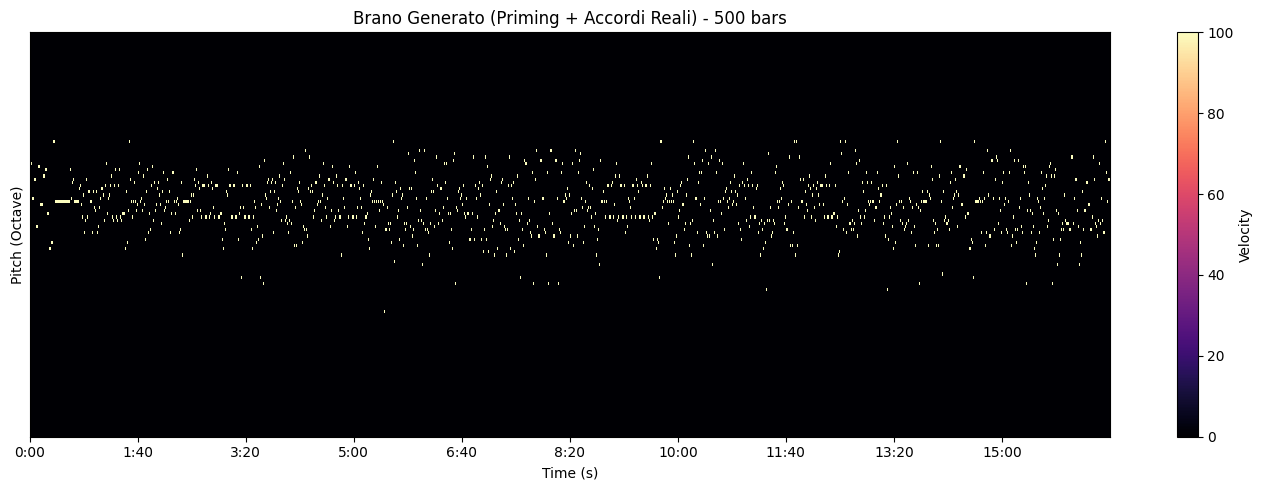

In [ ]:
# ==========================================
# 4. VISUALIZZAZIONE E AUDIO
# ==========================================
# Rimuoviamo Batch e Channel, moltiplichiamo per 100 per le dinamiche MIDI
final_piano_roll = concatenated_bars.detach().cpu().squeeze().numpy() * 100

concatenated_pm = piano_roll_to_pretty_midi(final_piano_roll, fs=8)

display_prettymidi(
    concatenated_pm, 
    fs=8, 
    title=f"Brano Generato (Priming + Accordi Reali) - {total_bars} bars"
)

audio = IPython.display.Audio(concatenated_pm.fluidsynth(fs=16000), rate=16000)
IPython.display.display(audio)

--- GROUND TRUTH MELODY (20 bars) ---


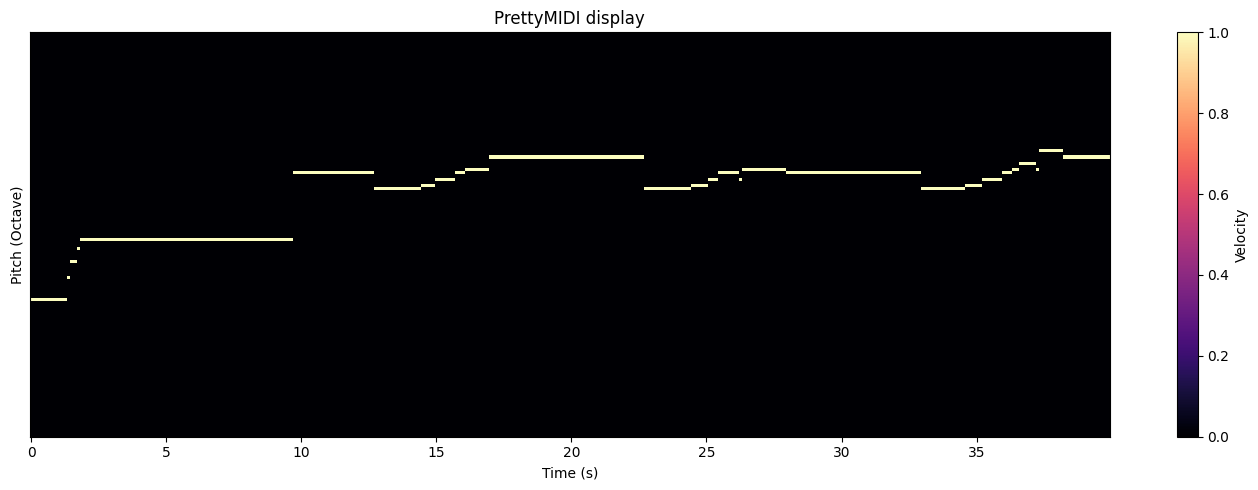


--- GENERATED MELODY (20 bars) ---


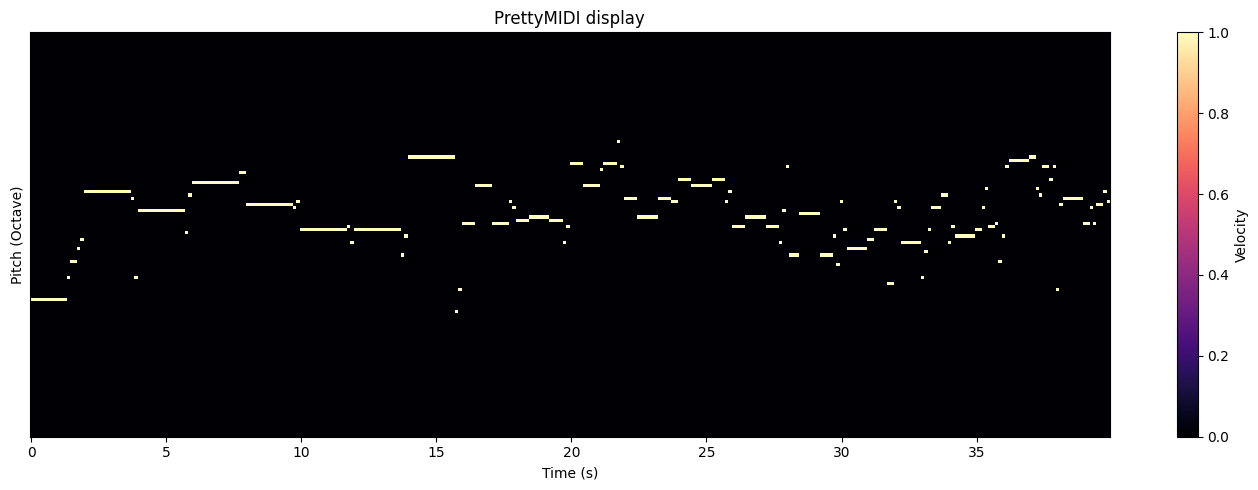


Results saved to output/ folder (real_melody.mid, generated_melody.mid)


In [22]:
# Comparison visualization

# 1. Convert real sequence to MIDI
# Ground truth bars are available as 'real_bars' from previous cells
# We slice them to match the length of the generated song (total_bars)
import numpy as np
num_viz_bars = total_bars
real_piano_roll = np.concatenate([bar for bar in real_bars[:num_viz_bars]], axis=1)
pm_real = piano_roll_to_pretty_midi(real_piano_roll, fs=8)

# 2. Get generated sequence
gen_piano_roll = concatenated_bars[0, 0].cpu().numpy()
pm_gen = piano_roll_to_pretty_midi(gen_piano_roll, fs=8)

print(f"--- GROUND TRUTH MELODY ({num_viz_bars} bars) ---")
display_prettymidi(pm_real)

print(f"\n--- GENERATED MELODY ({num_viz_bars} bars) ---")
display_prettymidi(pm_gen)

# Save both to output folder
import os
os.makedirs('output', exist_ok=True)
pm_real.write('output/real_melody.mid')
pm_gen.write('output/generated_melody.mid')
print("\nResults saved to output/ folder (real_melody.mid, generated_melody.mid)")